<a href="https://colab.research.google.com/github/hridibazaman03/220142_SVM/blob/main/220142_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve
)

from sklearn.decomposition import PCA

In [33]:
url = "https://raw.githubusercontent.com/hridibazaman03/220142_SVM/main/adult.csv"

df = pd.read_csv(url)

print(df.shape)
df.head()
print(df.columns)

(32561, 15)
Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')


In [35]:
print(df.isnull().sum())

df.replace('?', np.nan, inplace=True)

imputer = SimpleImputer(strategy='most_frequent')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [36]:
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [37]:
X = df.drop("income", axis=1)
y = df["income"]

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(22792, 14) (4884, 14) (4885, 14)


In [24]:
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": [0.1, 0.01],
    "kernel": ["rbf", "linear"]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    scoring="accuracy",
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


In [25]:
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

SVC(C=1, gamma=0.1)

In [26]:
y_pred = best_model.predict(X_test)
y_score = best_model.decision_function(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_score))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8460593654042988
Precision: 0.75
Recall: 0.5408163265306123
F1 Score: 0.6284584980237155
AUC: 0.8799465998316286

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      3709
           1       0.75      0.54      0.63      1176

    accuracy                           0.85      4885
   macro avg       0.81      0.74      0.77      4885
weighted avg       0.84      0.85      0.84      4885



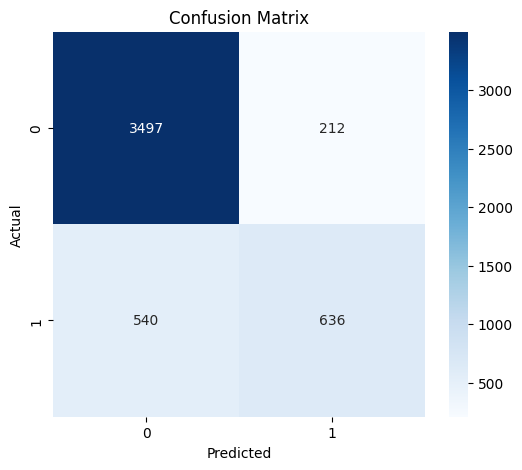

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

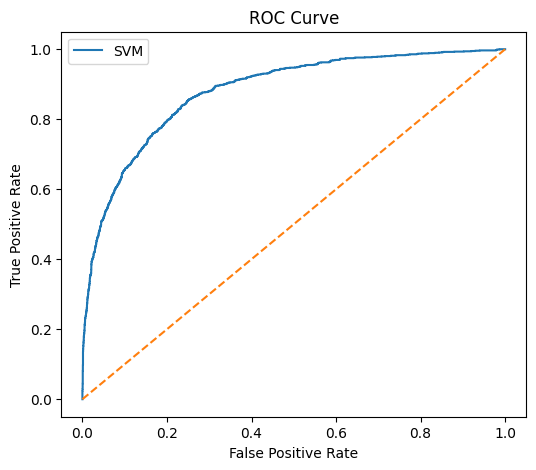

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_score)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="SVM")
plt.plot([0,1],[0,1],"--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [30]:
sample = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20],
    "Score": y_score[:20]
})

print(sample)

    Actual  Predicted     Score
0        0          0 -1.502595
1        0          0 -1.445869
2        0          0 -1.256177
3        0          0 -1.155566
4        0          0 -1.000156
5        0          0 -0.474098
6        0          0 -1.410952
7        0          0 -1.017921
8        1          0 -1.013770
9        0          0 -1.056151
10       0          0 -0.988280
11       0          0 -1.336527
12       0          0 -1.416623
13       0          0 -1.905796
14       1          1  1.758973
15       0          0 -0.997010
16       1          1  0.197024
17       0          0 -1.059794
18       0          0 -1.402153
19       0          0 -1.638663


In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

svm_2d = SVC(kernel="rbf")
svm_2d.fit(X_train_pca, y_train_pca)

SVC()

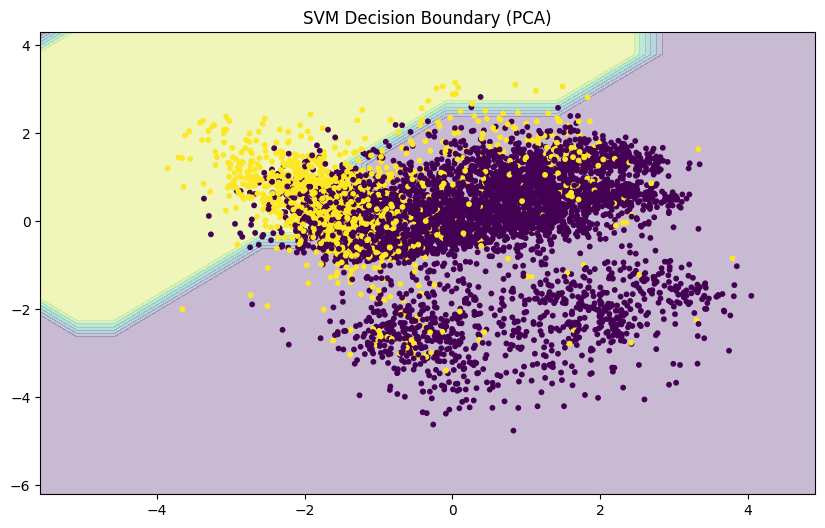

In [32]:
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.5),
    np.arange(y_min, y_max, 0.5)
)

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_test_pca[:,0], X_test_pca[:,1],
            c=y_test_pca, s=10)

plt.title("SVM Decision Boundary (PCA)")
plt.show()